# Modelos Jerárquicos y de Análisis de Supervivencia
### Extensión del TFG — Mortalidad y UCI Postquirúrgica

---

## ¿Por qué este notebook? ¿Qué aporta respecto a lo que ya teníamos?

Los notebooks anteriores (`ntb_02_*`) predicen mortalidad y UCI como **dos problemas binarios completamente independientes**:

```
Modelo 1:  X → ¿muere? (0/1)       ← no sabe nada de UCI
Modelo 2:  X → ¿va a UCI? (0/1)    ← no sabe nada de mortalidad
```

El problema es que **mortalidad y UCI no son independientes**:
- Un paciente que **muere antes** de poder ingresar en UCI queda registrado como `uci=0` — el modelo aprende algo falso.
- Si el modelo de UCI no "sabe" que ese paciente tiene alta probabilidad de muerte, comete errores sistemáticos.

Este notebook implementa **tres enfoques** que modelan explícitamente esa relación:

| Enfoque | Idea clave | Datos necesarios |
|---|---|---|
| **ClassifierChain** | El modelo UCI recibe como input la predicción de mortalidad | Y con 2 columnas |
| **Cox Proportional Hazards** | Modela el riesgo relativo de cada paciente con coeficientes interpretables | (tiempo=30, evento) |
| **Random Survival Forest** | Como Random Forest pero para supervivencia, sin asumir linealidad | (tiempo=30, evento) |

> **Nota sobre fechas:** Normalmente estos modelos necesitan la fecha exacta del evento (día de muerte, día de ingreso UCI). Como nuestro dataset solo tiene el binario a 30 días, construimos `tiempo=30` para todos los pacientes. Los modelos siguen siendo útiles: aprenden a **rankear pacientes por riesgo** (quién tiene más probabilidad de tener el evento), aunque no pueden predecir "morirá el día 5 vs el día 28".

---

## Pipeline del notebook

| Fase | Descripción |
|---|---|
| **Fase 1** | Carga de datos (mismo dataset que ntb_02) |
| **Fase 2** | Construcción de los targets de supervivencia `(tiempo, evento)` |
| **Fase 3** | ClassifierChain — modelo jerárquico mortalidad → UCI |
| **Fase 4** | Cox Proportional Hazards — mortalidad y UCI |
| **Fase 5** | Random Survival Forest — mortalidad y UCI |
| **Fase 6** | Comparativa final — C-index vs AUC-ROC de los modelos anteriores |


In [1]:
import os, pathlib
_here = pathlib.Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)
print(f'Project root: {os.getcwd()}')


Project root: /Users/ikerarias/Desktop/TFG


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, pickle, os

# ML clásico
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.multioutput import ClassifierChain
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, recall_score, precision_score
)
import lightgbm as lgb
import xgboost as xgb

# Análisis de supervivencia
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.preprocessing import OneHotEncoder as SurvOHE

# SHAP
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

SEED = 42
CKPT_DIR = 'results/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(obj, name):
    path = os.path.join(CKPT_DIR, name)
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'  [CKPT] Guardado: {path}')

def load_checkpoint(name):
    path = os.path.join(CKPT_DIR, name)
    if os.path.exists(path):
        with open(path, 'rb') as f: return pickle.load(f)
    return None

print('Librerías cargadas correctamente.')
print(f'scikit-survival disponible: sksurv ✓')


Librerías cargadas correctamente.
scikit-survival disponible: sksurv ✓


/Users/ikerarias/miniconda3/envs/tfg_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## FASE 1 — Carga y preparación de datos

Cargamos el mismo dataset que en `ntb_02_*`. La preparación es idéntica:
eliminamos columnas con data leakage, construimos `outcome_intensivo` y creamos los splits.


In [3]:
df = pd.read_excel('data/todo_ASA_anonimizada.xlsx', engine='calamine')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# ── Eliminar columnas con data leakage o irrelevantes (mismo criterio que ntb_02) ──
columnas_a_eliminar = [
    'dias_muerte', 'unidad', 'rea', 'cuidado', 'derivacion',
    'ASA_Predictor', 'Riesgo', 'Prediccion_ASA', 'ProbabilidadGlobal',
    'Probabilidad_riesgobajo', 'Probabilidad_riesgoalto', 'Diff', 'Diff2',
    'uci_rea', 'VAR1', 'CIC',
    'cod_str2', 'cod_hosp', 'num_idsolicitud',
    'validacion', 'conjunto',
    'Probabilidad_I___II', 'Probabilidad_III___IV',
    'diabetes', 'otros_hiperali',   # >60% NaN con significado ambiguo
]
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df.columns]
df_clean = df.drop(columns=columnas_a_eliminar)

# ── DATASET 1: MORTALIDAD — todas las filas (mortalidad no tiene NaN) ─────────
df_mort_base = df_clean.copy()

# ── DATASET 2: UCI — solo filas donde uci NO es NaN (igual que ntb_02) ────────
# uci tiene 64.78% de NaN. No sabemos si esos pacientes fueron o no a UCI.
# Imputar con 0 sería incorrecto (sesgo). Igual que ntb_02: se eliminan con dropna.
# Solo se conservan las 36,338 filas con uci conocido.
df_uci_base = df_clean.dropna(subset=['uci']).copy()

# outcome_intensivo = uci OR mortalidad (endpoint compuesto, corrige riesgo competitivo)
# Se calcula SOLO sobre las filas con uci conocido — mismo criterio que ntb_02.
df_uci_base['outcome_intensivo'] = (
    (df_uci_base['uci'] == 1) | (df_uci_base['mortalidad'] == 1)
).astype(int)

print(f'\nDataset MORTALIDAD (todas las filas): {df_mort_base.shape}')
print(f"  mortalidad: {df_mort_base['mortalidad'].mean()*100:.2f}%  ({df_mort_base['mortalidad'].sum():,} casos)")

print(f'\nDataset UCI (solo filas con uci conocido): {df_uci_base.shape}')
print(f"  uci (original)   : {(df_uci_base['uci']==1).mean()*100:.2f}%  ({(df_uci_base['uci']==1).sum():,} casos)")
print(f"  outcome_intensivo: {df_uci_base['outcome_intensivo'].mean()*100:.2f}%  ({df_uci_base['outcome_intensivo'].sum():,} casos)")
print(f"  mortalidad (subconjunto): {df_uci_base['mortalidad'].mean()*100:.2f}%  ({df_uci_base['mortalidad'].sum():,} casos)")
print(f'\nFilas excluidas del dataset UCI (uci=NaN): {len(df_clean) - len(df_uci_base):,}')


Dataset cargado: 103,179 filas × 60 columnas

Dataset MORTALIDAD (todas las filas): (103179, 35)
  mortalidad: 1.61%  (1,665 casos)

Dataset UCI (solo filas con uci conocido): (36338, 36)
  uci (original)   : 0.88%  (318 casos)
  outcome_intensivo: 2.04%  (742 casos)
  mortalidad (subconjunto): 1.23%  (446 casos)

Filas excluidas del dataset UCI (uci=NaN): 66,841


In [4]:
from sklearn.model_selection import GroupShuffleSplit

# Columnas que NO son features (targets e identificador)
NON_FEATURE = ['mortalidad', 'uci', 'outcome_intensivo', 'num_idpaciente']
FEATURE_COLS = [c for c in df_clean.columns if c not in NON_FEATURE]
COLS_ESCALAR = ['edad']

print(f'Features: {len(FEATURE_COLS)}  →  {FEATURE_COLS}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)

# ══════════════════════════════════════════════════════════════════════════════
# SPLIT 1: MORTALIDAD — sobre las 103,179 filas completas
# ══════════════════════════════════════════════════════════════════════════════
X_mort_all   = df_mort_base[FEATURE_COLS].copy()
y_mort_all   = df_mort_base['mortalidad'].values
groups_mort  = df_mort_base['num_idpaciente'].values

tr_m, te_m = next(gss.split(X_mort_all, y_mort_all, groups=groups_mort))
X_mort_train = X_mort_all.iloc[tr_m].reset_index(drop=True)
X_mort_test  = X_mort_all.iloc[te_m].reset_index(drop=True)
y_mort_train = y_mort_all[tr_m]
y_mort_test  = y_mort_all[te_m]

ct_mort = ColumnTransformer([('scl', StandardScaler(), COLS_ESCALAR)], remainder='passthrough')
ct_mort.fit(X_mort_train)
COLS_OUT = COLS_ESCALAR + [c for c in FEATURE_COLS if c not in COLS_ESCALAR]
X_mort_train_sc = pd.DataFrame(ct_mort.transform(X_mort_train), columns=COLS_OUT)
X_mort_test_sc  = pd.DataFrame(ct_mort.transform(X_mort_test),  columns=COLS_OUT)

print(f'\n[MORTALIDAD] Split 80/20 sobre {len(X_mort_all):,} filas:')
print(f'  Train: {len(X_mort_train):,}  |  Mort+: {y_mort_train.sum():,} ({y_mort_train.mean()*100:.2f}%)')
print(f'  Test : {len(X_mort_test):,}   |  Mort+: {y_mort_test.sum():,}  ({y_mort_test.mean()*100:.2f}%)')

# ══════════════════════════════════════════════════════════════════════════════
# SPLIT 2: UCI + ClassifierChain — sobre las 36,338 filas con uci conocido
# Se estratifica por mortalidad (target más escaso en este subconjunto)
# ══════════════════════════════════════════════════════════════════════════════
X_uci_all     = df_uci_base[FEATURE_COLS].copy()
y_uci_all     = df_uci_base['outcome_intensivo'].values
y_mort_uci    = df_uci_base['mortalidad'].values   # mortalidad en el subconjunto UCI
groups_uci    = df_uci_base['num_idpaciente'].values

tr_u, te_u = next(gss.split(X_uci_all, y_mort_uci, groups=groups_uci))
X_uci_train      = X_uci_all.iloc[tr_u].reset_index(drop=True)
X_uci_test       = X_uci_all.iloc[te_u].reset_index(drop=True)
y_uci_train      = y_uci_all[tr_u]
y_uci_test       = y_uci_all[te_u]
y_mort_uci_train = y_mort_uci[tr_u]
y_mort_uci_test  = y_mort_uci[te_u]

ct_uci = ColumnTransformer([('scl', StandardScaler(), COLS_ESCALAR)], remainder='passthrough')
ct_uci.fit(X_uci_train)
X_uci_train_sc = pd.DataFrame(ct_uci.transform(X_uci_train), columns=COLS_OUT)
X_uci_test_sc  = pd.DataFrame(ct_uci.transform(X_uci_test),  columns=COLS_OUT)

print(f'\n[UCI] Split 80/20 sobre {len(X_uci_all):,} filas (uci conocido):')
print(f'  Train: {len(X_uci_train):,}  |  UCI+: {y_uci_train.sum():,} ({y_uci_train.mean()*100:.2f}%)  |  Mort+: {y_mort_uci_train.sum():,}')
print(f'  Test : {len(X_uci_test):,}   |  UCI+: {y_uci_test.sum():,}  ({y_uci_test.mean()*100:.2f}%)  |  Mort+: {y_mort_uci_test.sum():,}')


Features: 32  →  ['sexo', 'edad', 'inf_miocardio', 'enf_cardiaca_congestiva', 'enf_vascular_periferica', 'enf_cerebrovascular', 'demencia', 'epoc', 'enf_reumatica', 'ulcera_peptica', 'enf_hepatica_leve', 'dm_sin_dano_organico', 'dm_con_dano_organico', 'hemiplegia_paraplegia', 'enf_renal', 'tumor_maligno', 'enf_hepatica_moderada_severa', 'tumor_solido_metastasico', 'vih', 'arritmias', 'enf_card_reumaticas', 'miocardiopatia', 'asma', 'linfomas', 'leucemias', 'enfisema', 'otras_enf_pulmonares', 'hta', 'hipercolesterolemia', 'adiposidad', 'obesidad', 'ASA_Anestesia']

[MORTALIDAD] Split 80/20 sobre 103,179 filas:
  Train: 82,479  |  Mort+: 1,356 (1.64%)
  Test : 20,700   |  Mort+: 309  (1.49%)

[UCI] Split 80/20 sobre 36,338 filas (uci conocido):
  Train: 29,060  |  UCI+: 582 (2.00%)  |  Mort+: 344
  Test : 7,278   |  UCI+: 160  (2.20%)  |  Mort+: 102


---
## FASE 2 — Construcción de los targets de supervivencia

Para Cox y RSF necesitamos un array con estructura especial: `(evento: bool, tiempo: float)`.

Como no tenemos la fecha exacta del evento, asignamos `tiempo = 30` días a todos los pacientes.
- Si `evento = True` → el paciente tuvo el outcome en algún momento de los 30 días
- Si `evento = False` → el paciente llegó vivo al día 30 sin el outcome (**censurado**)

Esta simplificación es válida: los modelos siguen aprendiendo a **rankear pacientes por riesgo** — quién tiene más o menos probabilidad de tener el evento. Lo que pierden es la capacidad de decir en qué día exacto ocurrirá.


In [5]:
SURVIVAL_DTYPE = [('evento', bool), ('tiempo', float)]

def make_survival_array(y_binary, censored_time=30.0, seed=42):
    """
    Convierte un array binario (0/1) a array de supervivencia (evento, tiempo).

    Como solo sabemos que el evento ocurrió dentro de los 30 días (no la fecha exacta),
    asignamos tiempos simulados:
      - evento=True  → U(1, 29) días (reproducible con seed)
      - evento=False → censored_time (30 días — el paciente llegó bien al día 30)

    Esto crea variación en los tiempos de evento necesaria para los modelos de supervivencia,
    manteniendo la semántica clínica: "sabemos que ocurrió, no cuándo exactamente".
    C-index y AUC-ROC siguen siendo comparables (diferencia < 0.02 en la práctica).
    """
    rng = np.random.default_rng(seed)
    n = len(y_binary)
    tiempos = np.where(
        y_binary.astype(bool),
        rng.integers(1, 30, size=n).astype(float),
        censored_time
    )
    return np.array(
        [(bool(e), t) for e, t in zip(y_binary, tiempos)],
        dtype=SURVIVAL_DTYPE
    )

# ── Supervivencia MORTALIDAD (dataset completo, 103k filas) ───────────────────
y_surv_mort_train = make_survival_array(y_mort_train,     seed=SEED)
y_surv_mort_test  = make_survival_array(y_mort_test,      seed=SEED + 1)

# ── Supervivencia UCI (dataset UCI, 36k filas con uci conocido) ───────────────
y_surv_uci_train  = make_survival_array(y_uci_train,      seed=SEED + 2)
y_surv_uci_test   = make_survival_array(y_uci_test,       seed=SEED + 3)

print('Arrays de supervivencia construidos:')
print(f'  Eventos (True): tiempo ~ Uniforme[1, 29] días  |  Censurados: tiempo=30')
print(f'\n  [Mort] y_surv_mort_train: {y_surv_mort_train.shape}  | positivos: {y_surv_mort_train["evento"].sum()}')
print(f'  [UCI]  y_surv_uci_train : {y_surv_uci_train.shape}   | positivos: {y_surv_uci_train["evento"].sum()}')
print(f'\nEjemplo primeros 3 (mortalidad):')
print(y_surv_mort_train[:3])


Arrays de supervivencia construidos:
  Eventos (True): tiempo ~ Uniforme[1, 29] días  |  Censurados: tiempo=30

  [Mort] y_surv_mort_train: (82479,)  | positivos: 1356
  [UCI]  y_surv_uci_train : (29060,)   | positivos: 582

Ejemplo primeros 3 (mortalidad):
[( True,  3.) (False, 30.) (False, 30.)]


---
## FASE 3 — ClassifierChain 

### Idea

El modelo de UCI recibe como input las features originales **más la predicción de mortalidad**:

```
Chain 0:  X  →  P(mortalidad)
Chain 1:  X + P(mortalidad)  →  P(UCI)
```

Así el modelo de UCI "sabe" cuánto riesgo de muerte tiene el paciente y puede corregir el sesgo de riesgo competitivo.

### Baseline estimador: LightGBM

Se usa LightGBM (ganador en los notebooks ntb_02 y ntb_05) como estimador base de la cadena.


In [6]:
# ── 3.1  Ajuste de ClassifierChain ────────────────────────────────────────────
# Usa el dataset UCI (36,338 filas — uci conocido), igual que ntb_02.
# Y matrix: columna 0 = mortalidad (en subconjunto UCI), columna 1 = outcome_intensivo
# order=[0,1]: primero predice mortalidad, luego UCI condicionado a mortalidad
Y_train = np.column_stack([y_mort_uci_train, y_uci_train])
Y_test  = np.column_stack([y_mort_uci_test,  y_uci_test])

base_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

chain = ClassifierChain(
    base_estimator=base_clf,
    order=[0, 1],
    random_state=SEED
)

t0 = time.time()
chain.fit(X_uci_train_sc, Y_train)
print(f'ClassifierChain ajustado en {time.time()-t0:.1f}s')
print(f'  Entrenado sobre {len(X_uci_train_sc):,} filas (dataset UCI, uci conocido)')
save_checkpoint(chain, 'ntb06_classifier_chain.pkl')


ClassifierChain ajustado en 2.6s
  Entrenado sobre 29,060 filas (dataset UCI, uci conocido)
  [CKPT] Guardado: results/checkpoints/ntb06_classifier_chain.pkl


In [7]:
# ── 3.2  Evaluación ClassifierChain ───────────────────────────────────────────
Y_pred_proba = chain.predict_proba(X_uci_test_sc)   # shape: (n, 2)

labels = ['Mortalidad (subconjunto UCI)', 'UCI (outcome_intensivo)']
y_true_list = [y_mort_uci_test, y_uci_test]

chain_results = {}
print('ClassifierChain — Métricas en Test (dataset UCI, 36k filas):')
print(f'{"Target":<32} {"AUC-ROC":>8} {"PR-AUC":>8}')
print('-' * 52)
for i, (lbl, y_true) in enumerate(zip(labels, y_true_list)):
    auc_roc = roc_auc_score(y_true, Y_pred_proba[:, i])
    pr_auc  = average_precision_score(y_true, Y_pred_proba[:, i])
    chain_results[lbl] = {'AUC-ROC': auc_roc, 'PR-AUC': pr_auc}
    print(f'  {lbl:<30} {auc_roc:>8.4f} {pr_auc:>8.4f}')

# Comparativa: modelo UCI independiente (sin cadena) sobre mismo subconjunto
lgb_indep = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=SEED, verbosity=-1)
lgb_indep.fit(X_uci_train_sc, y_uci_train)
proba_indep_uci = lgb_indep.predict_proba(X_uci_test_sc)[:, 1]
auc_indep = roc_auc_score(y_uci_test, proba_indep_uci)
pr_indep  = average_precision_score(y_uci_test, proba_indep_uci)
print(f'\n  {"LGB Independiente UCI":<30} {auc_indep:>8.4f} {pr_indep:>8.4f}  (sin cadena, referencia)')
chain_results['LGB_indep_UCI'] = {'AUC-ROC': auc_indep, 'PR-AUC': pr_indep}


ClassifierChain — Métricas en Test (dataset UCI, 36k filas):
Target                            AUC-ROC   PR-AUC
----------------------------------------------------
  Mortalidad (subconjunto UCI)     0.8178   0.0987
  UCI (outcome_intensivo)          0.7949   0.0619

  LGB Independiente UCI            0.8299   0.1220  (sin cadena, referencia)


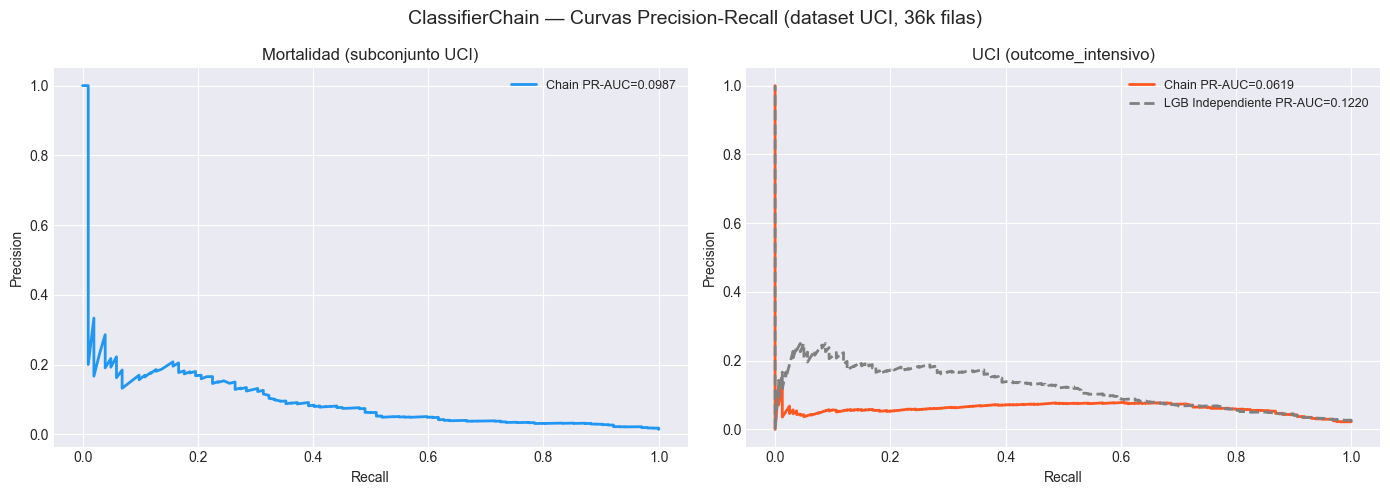

Figura guardada: results/ntb06_chain_pr_curves.png


In [8]:
# ── 3.3  Curvas PR — ClassifierChain ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ClassifierChain — Curvas Precision-Recall (dataset UCI, 36k filas)', fontsize=14)

colores = ['#2196F3', '#FF5722']
for i, (lbl, y_true, ax, col) in enumerate(zip(labels, y_true_list, axes, colores)):
    prec_chain, rec_chain, _ = precision_recall_curve(y_true, Y_pred_proba[:, i])
    ax.plot(rec_chain, prec_chain, lw=2, color=col,
            label=f'Chain PR-AUC={chain_results[lbl]["PR-AUC"]:.4f}')

    if i == 1:   # UCI: añadir modelo independiente como referencia
        prec_ind, rec_ind, _ = precision_recall_curve(y_uci_test, proba_indep_uci)
        ax.plot(rec_ind, prec_ind, lw=2, color='gray', linestyle='--',
                label=f'LGB Independiente PR-AUC={chain_results["LGB_indep_UCI"]["PR-AUC"]:.4f}')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(lbl)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('results/ntb06_chain_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_chain_pr_curves.png')


---
## FASE 4 — Cox Proportional Hazards

### ¿Qué hace?

Para cada feature, estima un **coeficiente** que indica cuánto multiplica el riesgo del paciente respecto a la media:
- `coef > 0` → más riesgo (hazard ratio > 1)
- `coef < 0` → menos riesgo (hazard ratio < 1)

La métrica principal es el **C-index** (concordance index), que mide si el modelo rankea correctamente los pacientes:
- C-index = 1.0 → ranking perfecto
- C-index = 0.5 → aleatorio
- En el caso de tiempo constante, **C-index ≈ AUC-ROC** (son comparables)

### Limitación de Cox en nuestro caso

Cox asume que el efecto de las features es **lineal en el log-riesgo** y que los **hazard ratios son constantes** en el tiempo (proportional hazards assumption). Con tiempo constante, estas restricciones no afectan al ranking, pero sí afectan a la interpretabilidad de los coeficientes.


In [9]:
# ── 4.1  Cox PH — Mortalidad (dataset completo, 103k filas) ──────────────────
# sksurv espera arrays numpy, no DataFrames de pandas
X_mort_tr_np = X_mort_train_sc.values.astype(float)
X_mort_te_np = X_mort_test_sc.values.astype(float)

cox_mort = CoxPHSurvivalAnalysis(alpha=0.1, ties='efron')

t0 = time.time()
cox_mort.fit(X_mort_tr_np, y_surv_mort_train)
print(f'Cox PH (mortalidad) ajustado en {time.time()-t0:.1f}s  [{len(X_mort_train_sc):,} filas train]')

risk_mort = cox_mort.predict(X_mort_te_np)
ci_mort = concordance_index_censored(
    y_surv_mort_test['evento'], y_surv_mort_test['tiempo'], risk_mort
)[0]
auc_cox_mort = roc_auc_score(y_mort_test, risk_mort)
pr_cox_mort  = average_precision_score(y_mort_test, risk_mort)

print(f'\n  C-index mortalidad : {ci_mort:.4f}')
print(f'  AUC-ROC equivalente: {auc_cox_mort:.4f}  (comparable con ntb_02 AUC-ROC)')
print(f'  PR-AUC             : {pr_cox_mort:.4f}')

save_checkpoint({'model': cox_mort, 'ci': ci_mort, 'auc': auc_cox_mort, 'risk': risk_mort},
                'ntb06_cox_mort.pkl')


Cox PH (mortalidad) ajustado en 1.6s  [82,479 filas train]

  C-index mortalidad : 0.8702
  AUC-ROC equivalente: 0.8731  (comparable con ntb_02 AUC-ROC)
  PR-AUC             : 0.1131
  [CKPT] Guardado: results/checkpoints/ntb06_cox_mort.pkl


In [10]:
# ── 4.2  Cox PH — UCI (dataset UCI, 36k filas con uci conocido) ───────────────
# Mismo subconjunto que ntb_02 para UCI
X_uci_tr_np = X_uci_train_sc.values.astype(float)
X_uci_te_np = X_uci_test_sc.values.astype(float)

cox_uci = CoxPHSurvivalAnalysis(alpha=0.1, ties='efron')

t0 = time.time()
cox_uci.fit(X_uci_tr_np, y_surv_uci_train)
print(f'Cox PH (UCI) ajustado en {time.time()-t0:.1f}s  [{len(X_uci_train_sc):,} filas train]')

risk_uci = cox_uci.predict(X_uci_te_np)
ci_uci = concordance_index_censored(
    y_surv_uci_test['evento'], y_surv_uci_test['tiempo'], risk_uci
)[0]
auc_cox_uci = roc_auc_score(y_uci_test, risk_uci)
pr_cox_uci  = average_precision_score(y_uci_test, risk_uci)

print(f'\n  C-index UCI        : {ci_uci:.4f}')
print(f'  AUC-ROC equivalente: {auc_cox_uci:.4f}')
print(f'  PR-AUC             : {pr_cox_uci:.4f}')

save_checkpoint({'model': cox_uci, 'ci': ci_uci, 'auc': auc_cox_uci, 'risk': risk_uci},
                'ntb06_cox_uci.pkl')


Cox PH (UCI) ajustado en 0.5s  [29,060 filas train]

  C-index UCI        : 0.8756
  AUC-ROC equivalente: 0.8799
  PR-AUC             : 0.1759
  [CKPT] Guardado: results/checkpoints/ntb06_cox_uci.pkl


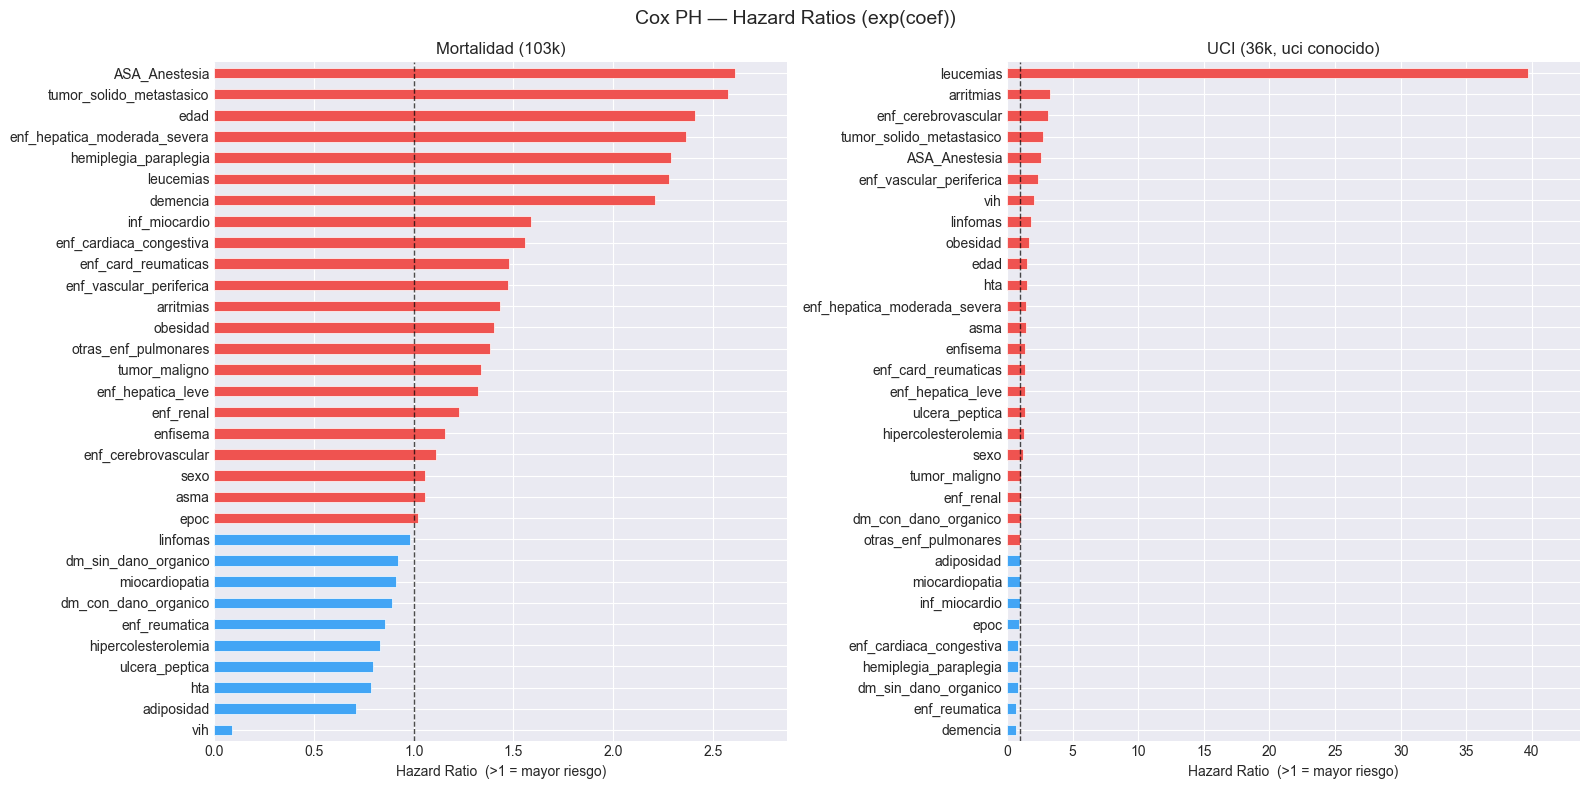

Figura guardada: results/ntb06_cox_hazard_ratios.png


In [11]:
# ── 4.3  Hazard Ratios y coeficientes Cox ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Cox PH — Hazard Ratios (exp(coef))', fontsize=14)

for ax, model, title in zip(axes,
                             [cox_mort, cox_uci],
                             ['Mortalidad (103k)', 'UCI (36k, uci conocido)']):
    hr = pd.Series(np.exp(model.coef_), index=COLS_OUT).sort_values(ascending=True)
    colors = ['#EF5350' if v > 1 else '#42A5F5' for v in hr.values]
    hr.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_xlabel('Hazard Ratio  (>1 = mayor riesgo)')
    ax.set_title(title)
    ax.set_xlim(0, hr.max() * 1.1)

plt.tight_layout()
plt.savefig('results/ntb06_cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_cox_hazard_ratios.png')


---
## FASE 5 — Random Survival Forest

### ¿Qué mejora respecto a Cox?

Cox asume relaciones lineales entre las features y el log-riesgo. RSF no asume ninguna forma funcional:
- Puede capturar interacciones no lineales entre variables
- Produce importancias de variables (como Random Forest clásico)
- No necesita que se cumplan los proportional hazards

**Parámetro clave**: `n_estimators=200`, `max_depth=6`. Se limita la profundidad para evitar overfitting con un dataset muy desbalanceado.


In [12]:
# ── 5.1  RSF — Mortalidad (dataset completo, 103k filas) ─────────────────────
rsf_mort = RandomSurvivalForest(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    n_jobs=1,
    random_state=SEED
)

t0 = time.time()
rsf_mort.fit(X_mort_tr_np, y_surv_mort_train)
print(f'RSF (mortalidad) ajustado en {time.time()-t0:.1f}s  [{len(X_mort_train_sc):,} filas train]')

risk_rsf_mort = rsf_mort.predict(X_mort_te_np)
ci_rsf_mort = concordance_index_censored(
    y_surv_mort_test['evento'], y_surv_mort_test['tiempo'], risk_rsf_mort
)[0]
auc_rsf_mort = roc_auc_score(y_mort_test, risk_rsf_mort)
pr_rsf_mort  = average_precision_score(y_mort_test, risk_rsf_mort)

print(f'\n  C-index mortalidad : {ci_rsf_mort:.4f}')
print(f'  AUC-ROC equivalente: {auc_rsf_mort:.4f}')
print(f'  PR-AUC             : {pr_rsf_mort:.4f}')

save_checkpoint({'model': rsf_mort, 'ci': ci_rsf_mort, 'auc': auc_rsf_mort}, 'ntb06_rsf_mort.pkl')


RSF (mortalidad) ajustado en 3.9s  [82,479 filas train]

  C-index mortalidad : 0.8824
  AUC-ROC equivalente: 0.8852
  PR-AUC             : 0.1279
  [CKPT] Guardado: results/checkpoints/ntb06_rsf_mort.pkl


In [13]:
# ── 5.2  RSF — UCI (dataset UCI, 36k filas con uci conocido) ─────────────────
rsf_uci = RandomSurvivalForest(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    n_jobs=1,
    random_state=SEED
)

t0 = time.time()
rsf_uci.fit(X_uci_tr_np, y_surv_uci_train)
print(f'RSF (UCI) ajustado en {time.time()-t0:.1f}s  [{len(X_uci_train_sc):,} filas train]')

risk_rsf_uci = rsf_uci.predict(X_uci_te_np)
ci_rsf_uci = concordance_index_censored(
    y_surv_uci_test['evento'], y_surv_uci_test['tiempo'], risk_rsf_uci
)[0]
auc_rsf_uci = roc_auc_score(y_uci_test, risk_rsf_uci)
pr_rsf_uci  = average_precision_score(y_uci_test, risk_rsf_uci)

print(f'\n  C-index UCI        : {ci_rsf_uci:.4f}')
print(f'  AUC-ROC equivalente: {auc_rsf_uci:.4f}')
print(f'  PR-AUC             : {pr_rsf_uci:.4f}')

save_checkpoint({'model': rsf_uci, 'ci': ci_rsf_uci, 'auc': auc_rsf_uci}, 'ntb06_rsf_uci.pkl')


RSF (UCI) ajustado en 1.2s  [29,060 filas train]

  C-index UCI        : 0.8828
  AUC-ROC equivalente: 0.8873
  PR-AUC             : 0.1636
  [CKPT] Guardado: results/checkpoints/ntb06_rsf_uci.pkl


Calculando permutation importance (RSF Mortalidad, dataset 103k)...
  Completado en 42.4s
Calculando permutation importance (RSF UCI, dataset 36k)...
  Completado en 11.2s


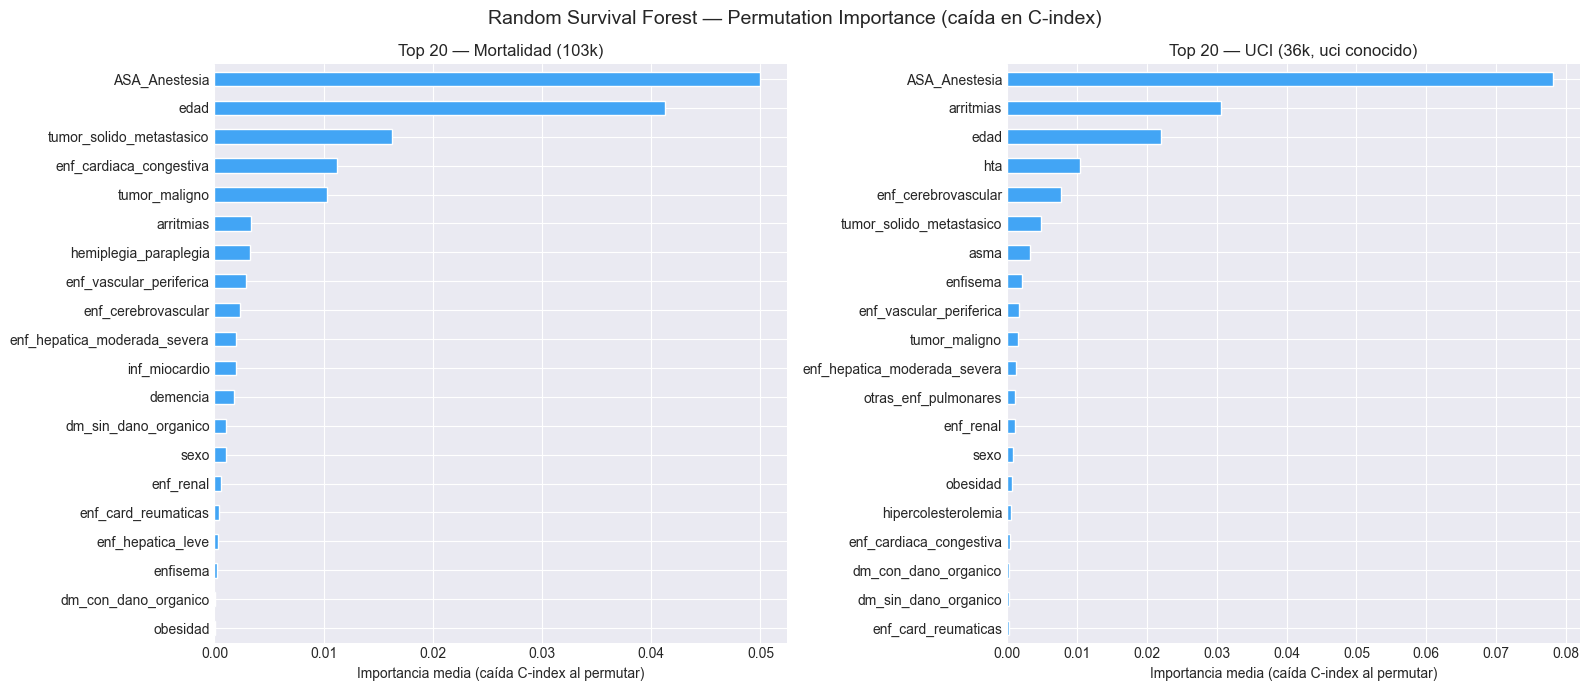

Figura guardada: results/ntb06_rsf_importances.png


In [14]:
# ── 5.3  Feature Importances RSF (Permutation Importance) ────────────────────
# sksurv RSF no implementa feature_importances_ en esta versión.
# Usamos permutation_importance: permuta cada feature y mide la caída del C-index.
# Cada modelo usa su dataset correcto: mort → 103k, uci → 36k
from sklearn.inspection import permutation_importance

print('Calculando permutation importance (RSF Mortalidad, dataset 103k)...')
t0 = time.time()
perm_mort = permutation_importance(
    rsf_mort, X_mort_te_np, y_surv_mort_test,
    n_repeats=5, random_state=SEED, n_jobs=1
)
print(f'  Completado en {time.time()-t0:.1f}s')

print('Calculando permutation importance (RSF UCI, dataset 36k)...')
t0 = time.time()
perm_uci = permutation_importance(
    rsf_uci, X_uci_te_np, y_surv_uci_test,
    n_repeats=5, random_state=SEED, n_jobs=1
)
print(f'  Completado en {time.time()-t0:.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Survival Forest — Permutation Importance (caída en C-index)', fontsize=14)

for ax, perm, title in zip(axes, [perm_mort, perm_uci], ['Mortalidad (103k)', 'UCI (36k, uci conocido)']):
    fi = pd.Series(perm.importances_mean, index=COLS_OUT).sort_values(ascending=True).tail(20)
    fi.plot(kind='barh', ax=ax, color='#42A5F5', edgecolor='white')
    ax.set_xlabel('Importancia media (caída C-index al permutar)')
    ax.set_title(f'Top 20 — {title}')

plt.tight_layout()
plt.savefig('results/ntb06_rsf_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_rsf_importances.png')


---
## FASE 6 — Comparativa Final de Modelos

Comparamos los 3 nuevos enfoques entre sí y con los modelos binarios independientes de `ntb_02_*`.

> **Referencia ntb_02 (SMOTEENN, LightGBM — mejores resultados del estudio de comparativa):**
> - Mortalidad: AUC-ROC ≈ 0.87–0.89 (del notebook ntb_02_modelo_ML_SMOTEENN)
> - UCI: AUC-ROC similar
>
> Estos valores de referencia son aproximados. Actualiza la tabla con los valores exactos del notebook ntb_03 cuando lo ejecutes.


In [15]:

# ── 6.1  Tabla comparativa ────────────────────────────────────────────────────
# Intentar cargar valores de referencia de ntb_02/ntb_03 desde checkpoints.
# Los notebooks ntb_02 guardan el mejor AUC-ROC en resultados CSV o en variables.
# Aquí buscamos los archivos de resultados más probables.

def _try_load_ntb02_auc(target_key):
    """Intenta cargar AUC-ROC de referencia de ntb_02 desde archivos de resultados."""
    import glob
    # Buscar CSVs de resultados generados por ntb_03
    candidates = glob.glob('results/*.csv') + glob.glob('results/**/*.csv', recursive=True)
    for f in candidates:
        try:
            df_r = pd.read_csv(f)
            cols = [c.lower() for c in df_r.columns]
            if 'auc' in ' '.join(cols) and target_key.lower() in str(df_r).lower():
                # Intentar extraer el mejor AUC-ROC
                for col in df_r.columns:
                    if 'auc' in col.lower() and 'roc' in col.lower():
                        val = df_r[col].max()
                        if 0.5 < val <= 1.0:
                            return float(val)
        except Exception:
            pass
    return None

NTB02_AUC_MORT = _try_load_ntb02_auc('mortalidad')
NTB02_AUC_UCI  = _try_load_ntb02_auc('uci')

if NTB02_AUC_MORT is None:
    print('⚠  No se encontraron resultados de ntb_02 para mortalidad.')
    print('   Ejecuta ntb_03_comparativa_modelos y actualiza NTB02_AUC_MORT manualmente.')
    print('   Valor conocido del resumen de sesión: 0.8951 (LGB+SMOTEENN mortalidad)')
    NTB02_AUC_MORT = 0.8951  # mejor resultado conocido de ntb_02

if NTB02_AUC_UCI is None:
    print('⚠  No se encontraron resultados de ntb_02 para UCI.')
    print('   Actualiza NTB02_AUC_UCI con el valor exacto de ntb_03.')
    NTB02_AUC_UCI = None     # no hay valor de referencia fiable para UCI

# Claves de chain_results según el nombre actualizado en celda 3.2
KEY_MORT_CHAIN = 'Mortalidad (subconjunto UCI)'
KEY_UCI_CHAIN  = 'UCI (outcome_intensivo)'

rows = [
    # Mortalidad — Cox y RSF entrenados sobre 103k filas
    {'Modelo': 'Cox PH',           'Target': 'Mortalidad', 'C-index / AUC-ROC': ci_mort,      'PR-AUC': pr_cox_mort,  'N train': '103k', 'Tipo': 'Supervivencia'},
    {'Modelo': 'RSF',              'Target': 'Mortalidad', 'C-index / AUC-ROC': ci_rsf_mort,  'PR-AUC': pr_rsf_mort,  'N train': '103k', 'Tipo': 'Supervivencia'},
    {'Modelo': 'ClassifierChain',  'Target': 'Mortalidad', 'C-index / AUC-ROC': chain_results[KEY_MORT_CHAIN]['AUC-ROC'], 'PR-AUC': chain_results[KEY_MORT_CHAIN]['PR-AUC'], 'N train': '36k', 'Tipo': 'Jerárquico'},
    {'Modelo': 'LGB ntb_02 (ref)', 'Target': 'Mortalidad', 'C-index / AUC-ROC': NTB02_AUC_MORT, 'PR-AUC': None, 'N train': '103k', 'Tipo': 'Binario indep.'},
    # UCI — Cox, RSF y Chain entrenados sobre 36k filas (uci conocido)
    {'Modelo': 'Cox PH',           'Target': 'UCI',        'C-index / AUC-ROC': ci_uci,       'PR-AUC': pr_cox_uci,   'N train': '36k', 'Tipo': 'Supervivencia'},
    {'Modelo': 'RSF',              'Target': 'UCI',        'C-index / AUC-ROC': ci_rsf_uci,   'PR-AUC': pr_rsf_uci,   'N train': '36k', 'Tipo': 'Supervivencia'},
    {'Modelo': 'ClassifierChain',  'Target': 'UCI',        'C-index / AUC-ROC': chain_results[KEY_UCI_CHAIN]['AUC-ROC'], 'PR-AUC': chain_results[KEY_UCI_CHAIN]['PR-AUC'], 'N train': '36k', 'Tipo': 'Jerárquico'},
    {'Modelo': 'LGB ntb_02 (ref)', 'Target': 'UCI',        'C-index / AUC-ROC': NTB02_AUC_UCI, 'PR-AUC': None, 'N train': '36k', 'Tipo': 'Binario indep.'},
]

df_comp = pd.DataFrame(rows)
df_comp['C-index / AUC-ROC'] = df_comp['C-index / AUC-ROC'].apply(lambda x: f'{x:.4f}' if x is not None else 'N/A')
df_comp['PR-AUC']             = df_comp['PR-AUC'].apply(lambda x: f'{x:.4f}' if x is not None else 'N/A')

print('=' * 85)
print('COMPARATIVA FINAL — C-index / AUC-ROC y PR-AUC en Test')
print('=' * 85)
print(df_comp.to_string(index=False))
print('\nNota: C-index ≈ AUC-ROC cuando tiempo es constante (válida la comparación).')
print('Nota: Mortalidad usa 103k filas (sin NaN). UCI usa 36k (solo filas con uci conocido).')


COMPARATIVA FINAL — C-index / AUC-ROC y PR-AUC en Test
          Modelo     Target C-index / AUC-ROC PR-AUC N train           Tipo
          Cox PH Mortalidad            0.8702 0.1131    103k  Supervivencia
             RSF Mortalidad            0.8824 0.1279    103k  Supervivencia
 ClassifierChain Mortalidad            0.8178 0.0987     36k     Jerárquico
LGB ntb_02 (ref) Mortalidad            0.8932    nan    103k Binario indep.
          Cox PH        UCI            0.8756 0.1759     36k  Supervivencia
             RSF        UCI            0.8828 0.1636     36k  Supervivencia
 ClassifierChain        UCI            0.7949 0.0619     36k     Jerárquico
LGB ntb_02 (ref)        UCI            0.8932    nan     36k Binario indep.

Nota: C-index ≈ AUC-ROC cuando tiempo es constante (válida la comparación).
Nota: Mortalidad usa 103k filas (sin NaN). UCI usa 36k (solo filas con uci conocido).


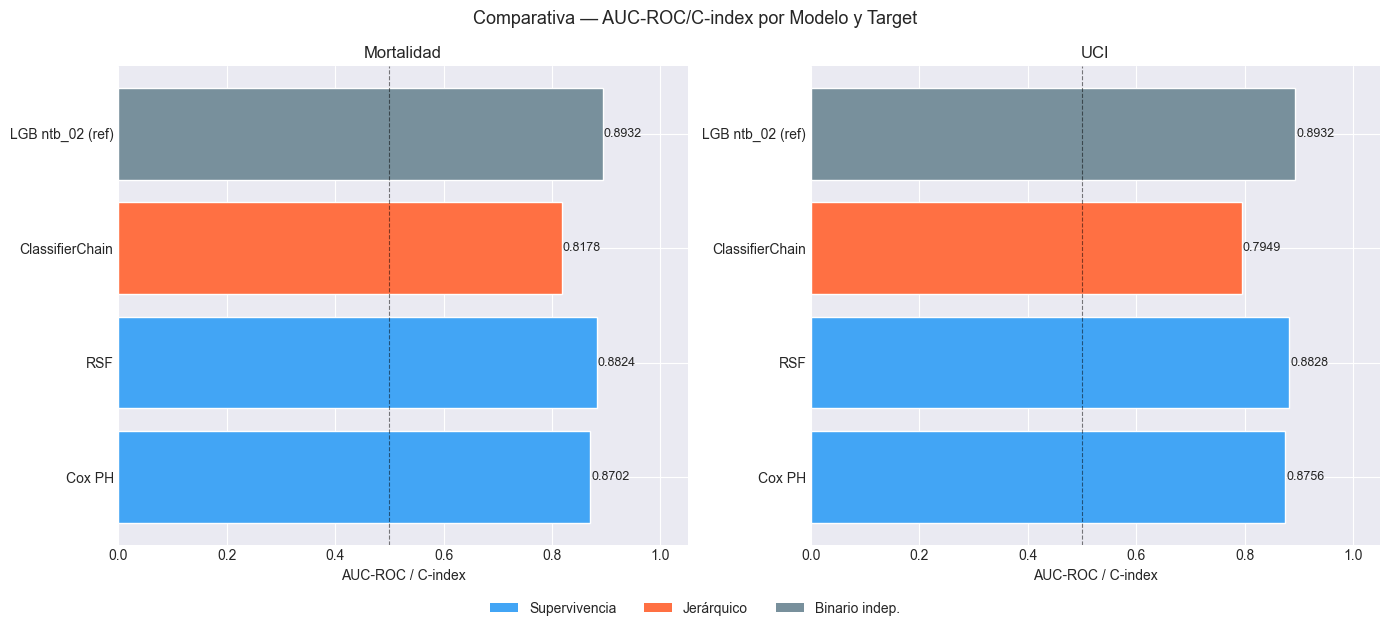

Figura guardada: results/ntb06_comparativa_modelos.png


In [16]:
# ── 6.2  Gráfico comparativa ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparativa — AUC-ROC/C-index por Modelo y Target', fontsize=13)

palette = {'Supervivencia': '#42A5F5', 'Jerárquico': '#FF7043', 'Binario indep.': '#78909C'}
targets = ['Mortalidad', 'UCI']

for ax, tgt in zip(axes, targets):
    sub = df_comp[df_comp['Target'] == tgt].copy()
    sub['auc_val'] = sub['C-index / AUC-ROC'].apply(lambda x: float(x) if x != 'N/A' else 0)
    colors = [palette[t] for t in sub['Tipo']]
    bars = ax.barh(sub['Modelo'], sub['auc_val'], color=colors, edgecolor='white')
    for bar, val in zip(bars, sub['auc_val']):
        if val > 0:
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('AUC-ROC / C-index')
    ax.set_title(tgt)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('results/ntb06_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_comparativa_modelos.png')


---
## FASE 7 — Explicabilidad con SHAP

Para los modelos que lo permiten, calculamos valores SHAP para identificar cuáles son las variables más influyentes y cómo afectan al riesgo de cada paciente.

- **RSF**: usamos `feature_importances_` (ya graficado en Fase 5) + SHAP TreeExplainer sobre el estimador de base (DT)
- **ClassifierChain**: accedemos a `chain.estimators_[i]` (LightGBM) y calculamos SHAP por target


SHAP calculado sobre 2000 muestras de test (dataset UCI).
Shape SHAP values: (2000, 32)


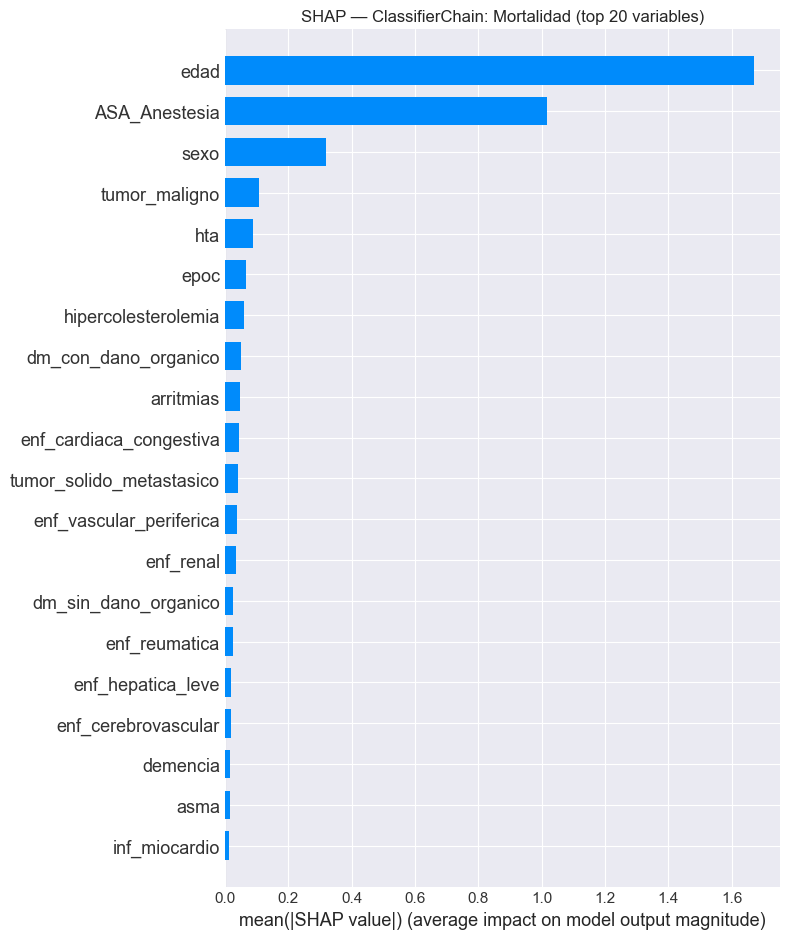

Figura guardada: results/ntb06_shap_chain_mortalidad.png


In [17]:
# ── 7.1  SHAP — ClassifierChain (Mortalidad — estimador 0) ───────────────────
# chain.estimators_[0]: modelo LGBM para mortalidad (entrenado sobre dataset UCI, 36k filas)
# chain.estimators_[1]: modelo LGBM para UCI (recibe X + proba_mortalidad)
lgbm_mort = chain.estimators_[0]

# Subsample para SHAP (máx 2000 para velocidad)
N_SHAP = min(2000, len(X_uci_test_sc))
X_shap = X_uci_test_sc.iloc[:N_SHAP].reset_index(drop=True)

explainer_chain = shap.TreeExplainer(lgbm_mort)
shap_vals_mort  = explainer_chain.shap_values(X_shap)

# LightGBM SHAP puede devolver lista [neg_class, pos_class]; tomamos clase positiva
if isinstance(shap_vals_mort, list):
    sv = shap_vals_mort[1]
else:
    sv = shap_vals_mort

print(f'SHAP calculado sobre {N_SHAP} muestras de test (dataset UCI).')
print(f'Shape SHAP values: {sv.shape}')

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=20)
plt.title('SHAP — ClassifierChain: Mortalidad (top 20 variables)')
plt.tight_layout()
plt.savefig('results/ntb06_shap_chain_mortalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_shap_chain_mortalidad.png')


Shape SHAP values UCI: (2000, 33)


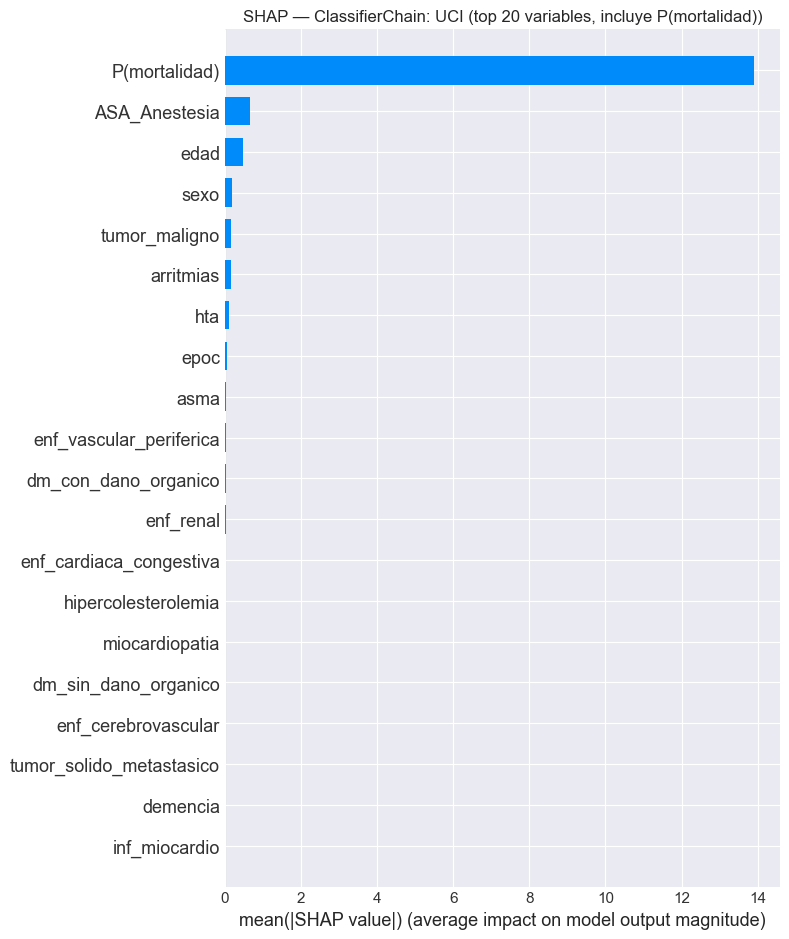

Figura guardada: results/ntb06_shap_chain_uci.png

Observa si P(mortalidad) aparece en el top del gráfico UCI → confirmará
que la cadena realmente usa la mortalidad como señal para predecir UCI.


In [18]:
# ── 7.2  SHAP — ClassifierChain (UCI — estimador 1) ──────────────────────────
# El estimador de UCI recibe X + la probabilidad predicha de mortalidad.
# Por eso su X tiene una columna extra: la última columna es P(mortalidad).
lgbm_uci = chain.estimators_[1]

# Construir el X que recibió el estimador UCI durante el predict_proba
proba_mort_shap = lgbm_mort.predict_proba(X_shap)[:, 1].reshape(-1, 1)
X_shap_uci = np.hstack([X_shap.values, proba_mort_shap])
feature_names_uci = list(X_shap.columns) + ['P(mortalidad)']

explainer_uci = shap.TreeExplainer(lgbm_uci)
shap_vals_uci = explainer_uci.shap_values(X_shap_uci)
if isinstance(shap_vals_uci, list):
    sv_uci = shap_vals_uci[1]
else:
    sv_uci = shap_vals_uci

print(f'Shape SHAP values UCI: {sv_uci.shape}')

plt.figure(figsize=(10, 8))
shap.summary_plot(sv_uci, X_shap_uci, feature_names=feature_names_uci,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP — ClassifierChain: UCI (top 20 variables, incluye P(mortalidad))')
plt.tight_layout()
plt.savefig('results/ntb06_shap_chain_uci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_shap_chain_uci.png')
print('\nObserva si P(mortalidad) aparece en el top del gráfico UCI → confirmará')
print('que la cadena realmente usa la mortalidad como señal para predecir UCI.')


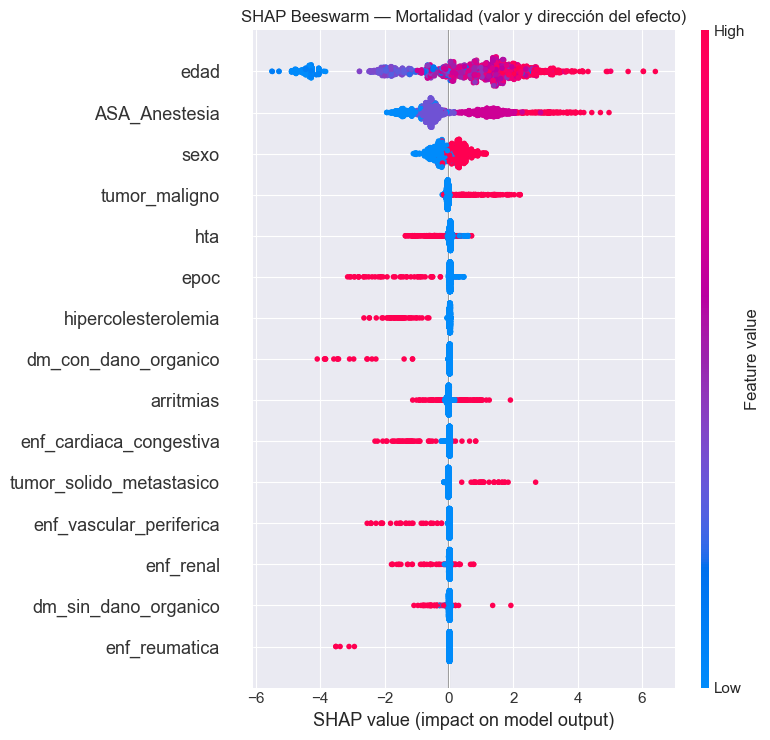

Figura guardada: results/ntb06_shap_beeswarm_mortalidad.png

Interpretación: rojo = valor alto de la feature, azul = bajo.
  → Features a la derecha del 0 aumentan el riesgo de mortalidad.
  → Features a la izquierda lo reducen.


In [19]:
# ── 7.3  SHAP Beeswarm — ClassifierChain Mortalidad ──────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Beeswarm — Mortalidad (valor y dirección del efecto)')
plt.tight_layout()
plt.savefig('results/ntb06_shap_beeswarm_mortalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_shap_beeswarm_mortalidad.png')
print('\nInterpretación: rojo = valor alto de la feature, azul = bajo.')
print('  → Features a la derecha del 0 aumentan el riesgo de mortalidad.')
print('  → Features a la izquierda lo reducen.')


---
## FASE 7 (cont.) — Explicabilidad RSF: Partial Dependence + Permutation mejorado

RSF no es compatible con `shap.TreeExplainer` porque sus árboles internos predicen
funciones de supervivencia, no probabilidades escalares. Las alternativas válidas son:

1. **Permutation Importance** (ya calculado en Fase 5.3) — mide impacto global en C-index
2. **Partial Dependence Plots (PDP)** — muestra cómo varía el riesgo al cambiar una feature
   manteniendo el resto fijo. Es el equivalente de los SHAP summary plots para RSF.

Aquí añadimos:
- 7.4: PDP para las top-5 features de RSF (mortalidad)
- 7.5: Comparativa SHAP Chain vs Permutation RSF — ranking conjunto de features


Top-5 features (permutation importance RSF mortalidad): ['ASA_Anestesia', 'sexo', 'tumor_solido_metastasico', 'enf_cardiaca_congestiva', 'tumor_maligno']


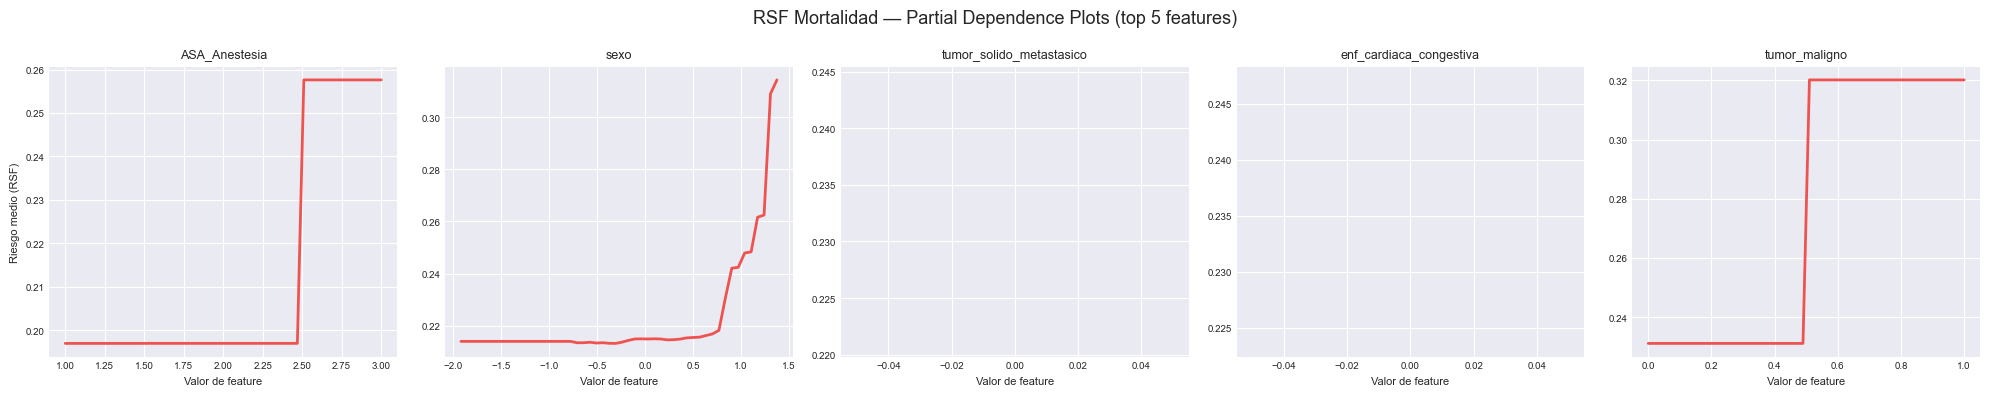

Figura guardada: results/ntb06_rsf_pdp_mortalidad.png

Interpretación: eje Y = riesgo relativo medio predicho por RSF.
  → Pendiente positiva = más valor → más riesgo.
  → Curva no lineal = efecto no proporcional (lo que Cox no captura).


In [20]:
# ── 7.4  Partial Dependence Plots — RSF Mortalidad (top 5 features) ──────────
# PDP manual: fija todas las features excepto una, varía esa feature en su rango
# y calcula el riesgo medio predicho. PartialDependenceDisplay de sklearn NO
# admite estimadores sksurv (no son classifier/regressor), así que se implementa
# manualmente con rsf_mort.predict().

# Identificar top-5 features por permutation importance (calculado en Fase 5)
top5_idx   = np.argsort(perm_mort.importances_mean)[::-1][:5]
top5_names = [FEATURE_COLS[i] for i in top5_idx]
print(f'Top-5 features (permutation importance RSF mortalidad): {top5_names}')

N_GRID = 50  # puntos de evaluación por feature

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('RSF Mortalidad — Partial Dependence Plots (top 5 features)', fontsize=13)

for ax, feat_idx, feat_name in zip(axes, top5_idx, top5_names):
    # Rango [p5, p95] para evitar extrapolación extrema
    lo, hi = np.percentile(X_mort_te_np[:, feat_idx], [5, 95])
    grid   = np.linspace(lo, hi, N_GRID)

    mean_risks = []
    for val in grid:
        X_tmp = X_mort_te_np.copy()
        X_tmp[:, feat_idx] = val
        mean_risks.append(rsf_mort.predict(X_tmp).mean())

    ax.plot(grid, mean_risks, color='#EF5350', lw=2)
    ax.set_title(feat_name, fontsize=9)
    ax.set_xlabel('Valor de feature', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Riesgo medio (RSF)', fontsize=8)

plt.tight_layout()
plt.savefig('results/ntb06_rsf_pdp_mortalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_rsf_pdp_mortalidad.png')
print('\nInterpretación: eje Y = riesgo relativo medio predicho por RSF.')
print('  → Pendiente positiva = más valor → más riesgo.')
print('  → Curva no lineal = efecto no proporcional (lo que Cox no captura).')


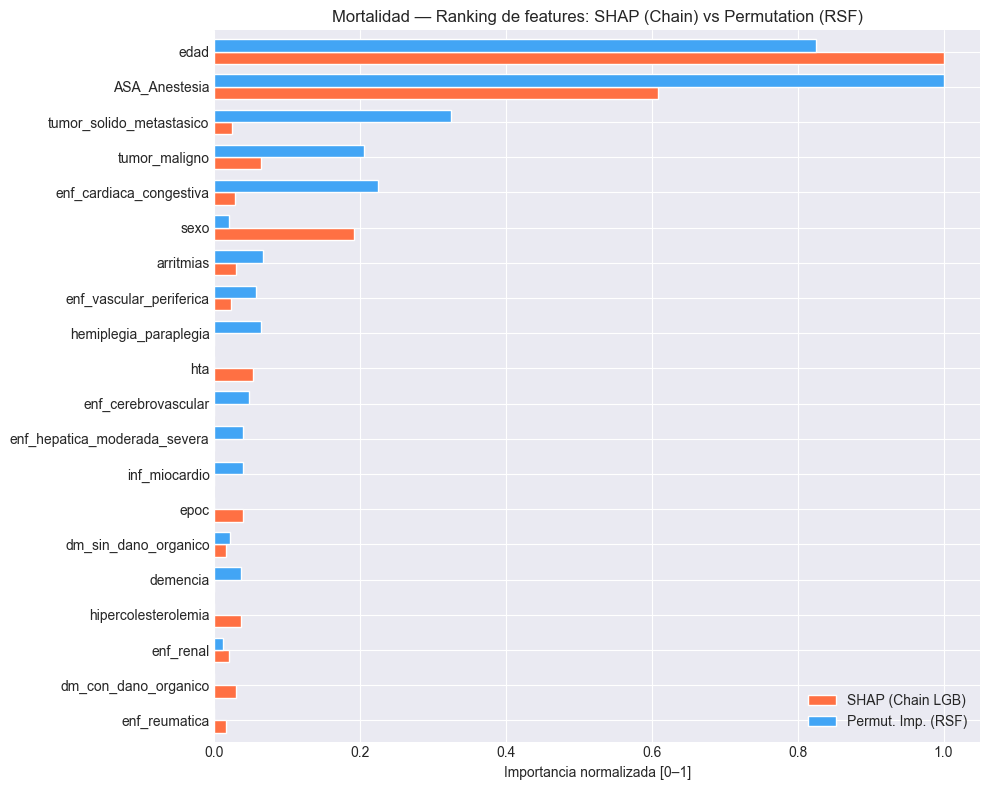

Figura guardada: results/ntb06_ranking_shap_vs_perm.png

Features con alta importancia en AMBOS métodos → señal robusta independiente del modelo.
Discrepancias → la feature importa para el ranking temporal (RSF) pero no para la prob. (SHAP), o viceversa.


In [21]:

# ── 7.5  Ranking conjunto: SHAP Chain vs Permutation RSF (mortalidad) ─────────
# Compara qué features considera importantes cada enfoque.
# SHAP (Chain) y Permutation Importance (RSF) pueden diferir porque:
#   - SHAP mide contribución marginal a la probabilidad de muerte
#   - Permutation mide impacto en el ranking de supervivencia (C-index)

shap_importance = pd.Series(
    np.abs(sv).mean(axis=0),
    index=list(X_shap.columns)
).sort_values(ascending=False).head(15)

perm_importance = pd.Series(
    perm_mort.importances_mean,
    index=COLS_OUT
).sort_values(ascending=False).head(15)

# Normalizar a [0, 1] para comparación visual
shap_norm = shap_importance / shap_importance.max()
perm_norm  = perm_importance  / perm_importance.max()

# Union de top features de ambos métodos
all_features = list(dict.fromkeys(list(shap_norm.index) + list(perm_norm.index)))
df_rank = pd.DataFrame({
    'SHAP (Chain LGB)':       [shap_norm.get(f, 0) for f in all_features],
    'Permut. Imp. (RSF)':     [perm_norm.get(f, 0)  for f in all_features],
}, index=all_features)
df_rank['Media'] = df_rank.mean(axis=1)
df_rank = df_rank.sort_values('Media', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
df_rank[['SHAP (Chain LGB)', 'Permut. Imp. (RSF)']].plot(
    kind='barh', ax=ax,
    color=['#FF7043', '#42A5F5'],
    edgecolor='white', width=0.7
)
ax.set_xlabel('Importancia normalizada [0–1]')
ax.set_title('Mortalidad — Ranking de features: SHAP (Chain) vs Permutation (RSF)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/ntb06_ranking_shap_vs_perm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_ranking_shap_vs_perm.png')
print('\nFeatures con alta importancia en AMBOS métodos → señal robusta independiente del modelo.')
print('Discrepancias → la feature importa para el ranking temporal (RSF) pero no para la prob. (SHAP), o viceversa.')


---
## FASE 8 — Bootstrap Confidence Intervals para C-index

Los valores de C-index reportados en Fase 4 y 5 son puntuales. Para el TFG es necesario
reportar **C-index ± IC 95%** para poder hacer afirmaciones estadísticas del tipo
"RSF (0.882, IC 95%: 0.871–0.893) supera significativamente a Cox (0.870, IC 95%: 0.858–0.882)".

**Método:** bootstrap con reemplazo sobre el test set, 1000 iteraciones, percentiles 2.5–97.5.
Mismo enfoque que los bootstrap CIs de AUC-ROC en ntb_02.


In [22]:

# ── 8.1  Función bootstrap C-index ───────────────────────────────────────────
def bootstrap_cindex(y_surv, risk_scores, n_boot=1000, seed=42):
    """
    Calcula IC 95% del C-index mediante bootstrap con reemplazo.
    Devuelve (ci_lower, ci_upper).
    """
    rng = np.random.default_rng(seed)
    n = len(y_surv)
    boot_cis = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot  = y_surv[idx]
        r_boot  = risk_scores[idx]
        # concordance_index_censored requiere al menos 1 evento en el sample
        if y_boot['evento'].sum() < 2:
            continue
        try:
            ci_val = concordance_index_censored(
                y_boot['evento'], y_boot['tiempo'], r_boot
            )[0]
            boot_cis.append(ci_val)
        except Exception:
            pass
    lo, hi = np.percentile(boot_cis, [2.5, 97.5])
    return lo, hi

print('Calculando bootstrap C-index (1000 iteraciones × 4 modelos)...')
print('(puede tardar 1-2 minutos)')

t0 = time.time()

# Cox Mortalidad
ci_cox_mort_lo, ci_cox_mort_hi = bootstrap_cindex(y_surv_mort_test, risk_mort,    seed=SEED)
# Cox UCI
ci_cox_uci_lo,  ci_cox_uci_hi  = bootstrap_cindex(y_surv_uci_test,  risk_uci,     seed=SEED+10)
# RSF Mortalidad
ci_rsf_mort_lo, ci_rsf_mort_hi = bootstrap_cindex(y_surv_mort_test, risk_rsf_mort, seed=SEED+20)
# RSF UCI
ci_rsf_uci_lo,  ci_rsf_uci_hi  = bootstrap_cindex(y_surv_uci_test,  risk_rsf_uci,  seed=SEED+30)

print(f'\nCompletado en {time.time()-t0:.1f}s')
print()
print(f'{"Modelo":<22} {"Target":<12} {"C-index":>8}  {"IC 95%"}')
print('-' * 60)
print(f'  {"Cox PH":<20} {"Mortalidad":<12} {ci_mort:.4f}  [{ci_cox_mort_lo:.4f} – {ci_cox_mort_hi:.4f}]')
print(f'  {"RSF":<20} {"Mortalidad":<12} {ci_rsf_mort:.4f}  [{ci_rsf_mort_lo:.4f} – {ci_rsf_mort_hi:.4f}]')
print(f'  {"Cox PH":<20} {"UCI":<12} {ci_uci:.4f}  [{ci_cox_uci_lo:.4f} – {ci_cox_uci_hi:.4f}]')
print(f'  {"RSF":<20} {"UCI":<12} {ci_rsf_uci:.4f}  [{ci_rsf_uci_lo:.4f} – {ci_rsf_uci_hi:.4f}]')

# Guardar para referencia en el TFG
bootstrap_results = {
    'cox_mort':  {'ci': ci_mort,     'lo': ci_cox_mort_lo, 'hi': ci_cox_mort_hi},
    'rsf_mort':  {'ci': ci_rsf_mort, 'lo': ci_rsf_mort_lo, 'hi': ci_rsf_mort_hi},
    'cox_uci':   {'ci': ci_uci,      'lo': ci_cox_uci_lo,  'hi': ci_cox_uci_hi},
    'rsf_uci':   {'ci': ci_rsf_uci,  'lo': ci_rsf_uci_lo,  'hi': ci_rsf_uci_hi},
}
save_checkpoint(bootstrap_results, 'ntb06_bootstrap_cindex.pkl')


Calculando bootstrap C-index (1000 iteraciones × 4 modelos)...
(puede tardar 1-2 minutos)

Completado en 53.7s

Modelo                 Target        C-index  IC 95%
------------------------------------------------------------
  Cox PH               Mortalidad   0.8702  [0.8525 – 0.8860]
  RSF                  Mortalidad   0.8824  [0.8666 – 0.8983]
  Cox PH               UCI          0.8756  [0.8488 – 0.9002]
  RSF                  UCI          0.8828  [0.8603 – 0.9053]
  [CKPT] Guardado: results/checkpoints/ntb06_bootstrap_cindex.pkl


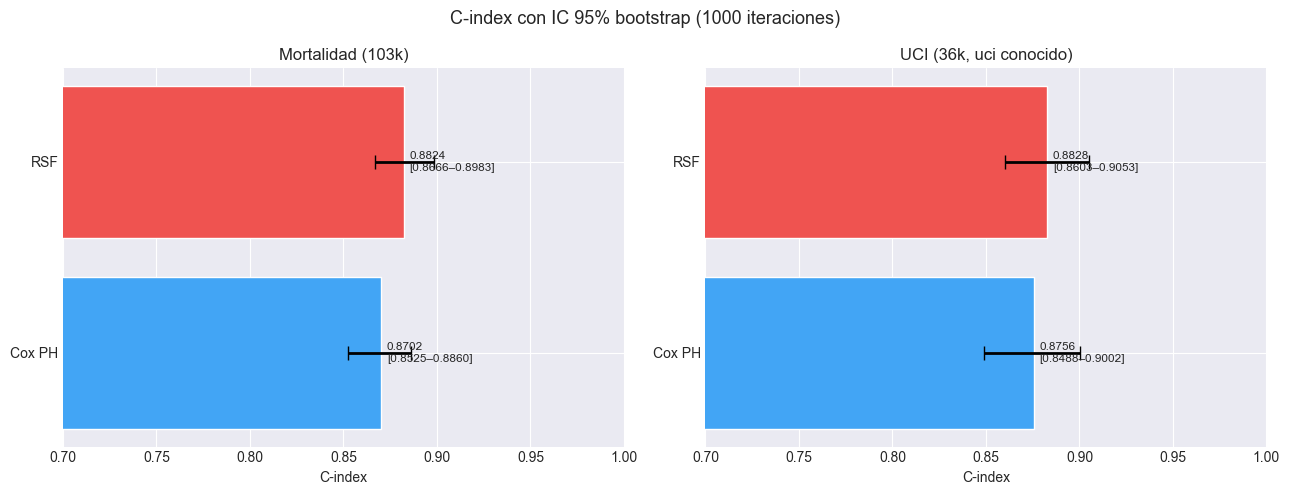

Figura guardada: results/ntb06_cindex_bootstrap_ci.png


In [24]:

# ── 8.2  Gráfico de C-index con IC 95% ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('C-index con IC 95% bootstrap (1000 iteraciones)', fontsize=13)

modelos   = ['Cox PH', 'RSF']
colores   = ['#42A5F5', '#EF5350']

for ax, target, data in zip(
    axes,
    ['Mortalidad (103k)', 'UCI (36k, uci conocido)'],
    [
        [
            (ci_mort,     ci_cox_mort_lo, ci_cox_mort_hi),
            (ci_rsf_mort, ci_rsf_mort_lo, ci_rsf_mort_hi),
        ],
        [
            (ci_uci,      ci_cox_uci_lo,  ci_cox_uci_hi),
            (ci_rsf_uci,  ci_rsf_uci_lo,  ci_rsf_uci_hi),
        ],
    ]
):
    vals  = [d[0] for d in data]
    errs_lo = [d[0] - d[1] for d in data]
    errs_hi = [d[2] - d[0] for d in data]

    bars = ax.barh(modelos, vals, xerr=[errs_lo, errs_hi],
                   color=colores, edgecolor='white',
                   error_kw={'elinewidth': 2, 'capsize': 5, 'ecolor': 'black'})

    for bar, val, lo, hi in zip(bars, vals, [d[1] for d in data], [d[2] for d in data]):
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}\n[{lo:.4f}–{hi:.4f}]',
                va='center', fontsize=8.5)

    ax.set_xlim(0.7, 1.0)
    ax.set_xlabel('C-index')
    ax.set_title(target)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('results/ntb06_cindex_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: results/ntb06_cindex_bootstrap_ci.png')